<a href="https://colab.research.google.com/github/ryouchinsa/Rectlabel-support/blob/master/notebooks/train_rf_detr_instance_segmentation_on_custom_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to Train a RF-DETR Instance Segmentation Model with Custom Data

We will show you how to train a RF-DETR instance segmentation model with your images and annotations and export to a Core ML model which can be used for auto labeling on RectLabel.

### Use GPU

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Runtime` -> `Change runtime type` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Wed Mar 25 16:18:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install PyTorch 2.8.0

In [ ]:
!pip install -q torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 86.1 MB/s eta 0:00:00


### Install RF-DETR 1.5.1

In [ ]:
!pip install -q rfdetr==1.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.9/187.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.9 MB/s eta 0:00:00


In [ ]:
!pip install -q rfdetr[train,loggers]==1.6.0

### Download training images and annotations

Download training images and annotations. You can use these or replace them with your own data.

In [ ]:
!mkdir datasets
%cd datasets
!wget -q https://huggingface.co/datasets/rectlabel/datasets/resolve/main/donut_coco.zip
!unzip -q donut_coco.zip
%cd ..

/content/datasets
/content


### Fine-tune RF-DETR on custom dataset

Start training from the current content folder.

In [ ]:
from rfdetr import RFDETRSegNano

model = RFDETRSegNano()
dataset_dir = "datasets/donut_coco"
model.train(dataset_dir=dataset_dir, epochs=20, batch_size=4, grad_accum_steps=4)

[2026-03-25 16:22:54] [INFO] rf-detr - Downloading pretrained weights for rf-detr-seg-nano.pt


rf-detr-seg-nano.pt:   0%|          | 0.00/128M [00:00<?, ?iB/s]

[2026-03-25 16:22:56] [INFO] rf-detr - MD5 validation successful for rf-detr-seg-nano.pt


[2026-03-25 16:22:56] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-25 16:22:56] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-25 16:22:58] [INFO] rf-detr - Loading pretrain weights


...

[2026-03-25 16:25:33] [INFO] rf-detr - Epoch: [6/10]  [0/5]  eta: 0:00:40  lr: 0.000100  class_error: 0.00  loss: 24.2742 (24.2742)  loss_ce: 2.8975 (2.8975)  loss_bbox: 0.1641 (0.1641)  loss_giou: 0.1737 (0.1737)  loss_mask_ce: 0.1300 (0.1300)  loss_mask_dice: 0.1133 (0.1133)  loss_ce_0: 5.2385 (5.2385)  loss_bbox_0: 0.1037 (0.1037)  loss_giou_0: 0.1046 (0.1046)  loss_mask_ce_0: 0.1472 (0.1472)  loss_mask_dice_0: 0.1306 (0.1306)  loss_ce_1: 3.6279 (3.6279)  loss_bbox_1: 0.1046 (0.1046)  loss_giou_1: 0.1094 (0.1094)  loss_mask_ce_1: 0.1457 (0.1457)  loss_mask_dice_1: 0.1172 (0.1172)  loss_ce_2: 3.4383 (3.4383)  loss_bbox_2: 0.1266 (0.1266)  loss_giou_2: 0.1340 (0.1340)  loss_mask_ce_2: 0.1431 (0.1431)  loss_mask_dice_2: 0.1229 (0.1229)  loss_ce_enc: 5.9708 (5.9708)  loss_bbox_enc: 0.3904 (0.3904)  loss_giou_enc: 0.2945 (0.2945)  loss_mask_ce_enc: 0.1677 (0.1677)  loss_mask_dice_enc: 0.1778 (0.1778)  loss_ce_unscaled: 0.5795 (0.5795)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-25 16:26:01] [INFO] rf-detr - Epoch: [7/10]  [0/5]  eta: 0:00:37  lr: 0.000100  class_error: 0.00  loss: 22.7435 (22.7435)  loss_ce: 2.1556 (2.1556)  loss_bbox: 0.1483 (0.1483)  loss_giou: 0.1917 (0.1917)  loss_mask_ce: 0.1584 (0.1584)  loss_mask_dice: 0.1203 (0.1203)  loss_ce_0: 4.9840 (4.9840)  loss_bbox_0: 0.1458 (0.1458)  loss_giou_0: 0.1663 (0.1663)  loss_mask_ce_0: 0.1553 (0.1553)  loss_mask_dice_0: 0.1511 (0.1511)  loss_ce_1: 3.5779 (3.5779)  loss_bbox_1: 0.1347 (0.1347)  loss_giou_1: 0.1720 (0.1720)  loss_mask_ce_1: 0.1561 (0.1561)  loss_mask_dice_1: 0.1402 (0.1402)  loss_ce_2: 2.8774 (2.8774)  loss_bbox_2: 0.1456 (0.1456)  loss_giou_2: 0.1784 (0.1784)  loss_mask_ce_2: 0.1537 (0.1537)  loss_mask_dice_2: 0.1470 (0.1470)  loss_ce_enc: 5.2114 (5.2114)  loss_bbox_enc: 0.6531 (0.6531)  loss_giou_enc: 0.4523 (0.4523)  loss_mask_ce_enc: 0.1656 (0.1656)  loss_mask_dice_enc: 0.2014 (0.2014)  loss_ce_unscaled: 0.4311 (0.4311)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-25 16:26:26] [INFO] rf-detr - Epoch: [8/10]  [0/5]  eta: 0:00:36  lr: 0.000100  class_error: 0.00  loss: 22.7046 (22.7046)  loss_ce: 2.0222 (2.0222)  loss_bbox: 0.3106 (0.3106)  loss_giou: 0.2306 (0.2306)  loss_mask_ce: 0.1613 (0.1613)  loss_mask_dice: 0.1069 (0.1069)  loss_ce_0: 4.9342 (4.9342)  loss_bbox_0: 0.2477 (0.2477)  loss_giou_0: 0.1811 (0.1811)  loss_mask_ce_0: 0.1879 (0.1879)  loss_mask_dice_0: 0.1497 (0.1497)  loss_ce_1: 3.2449 (3.2449)  loss_bbox_1: 0.2561 (0.2561)  loss_giou_1: 0.1967 (0.1967)  loss_mask_ce_1: 0.1686 (0.1686)  loss_mask_dice_1: 0.1209 (0.1209)  loss_ce_2: 2.6348 (2.6348)  loss_bbox_2: 0.2834 (0.2834)  loss_giou_2: 0.2038 (0.2038)  loss_mask_ce_2: 0.1694 (0.1694)  loss_mask_dice_2: 0.1202 (0.1202)  loss_ce_enc: 5.4024 (5.4024)  loss_bbox_enc: 0.4421 (0.4421)  loss_giou_enc: 0.2786 (0.2786)  loss_mask_ce_enc: 0.3721 (0.3721)  loss_mask_dice_enc: 0.2786 (0.2786)  loss_ce_unscaled: 0.4044 (0.4044)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-25 16:26:58] [INFO] rf-detr - Epoch: [9/10]  [0/5]  eta: 0:00:38  lr: 0.000100  class_error: 0.00  loss: 18.6519 (18.6519)  loss_ce: 1.6397 (1.6397)  loss_bbox: 0.1064 (0.1064)  loss_giou: 0.1447 (0.1447)  loss_mask_ce: 0.1395 (0.1395)  loss_mask_dice: 0.1317 (0.1317)  loss_ce_0: 4.4358 (4.4358)  loss_bbox_0: 0.1091 (0.1091)  loss_giou_0: 0.1321 (0.1321)  loss_mask_ce_0: 0.1187 (0.1187)  loss_mask_dice_0: 0.1210 (0.1210)  loss_ce_1: 2.8991 (2.8991)  loss_bbox_1: 0.0921 (0.0921)  loss_giou_1: 0.1205 (0.1205)  loss_mask_ce_1: 0.1198 (0.1198)  loss_mask_dice_1: 0.1145 (0.1145)  loss_ce_2: 2.0472 (2.0472)  loss_bbox_2: 0.1048 (0.1048)  loss_giou_2: 0.1328 (0.1328)  loss_mask_ce_2: 0.1175 (0.1175)  loss_mask_dice_2: 0.1407 (0.1407)  loss_ce_enc: 4.7040 (4.7040)  loss_bbox_enc: 0.3057 (0.3057)  loss_giou_enc: 0.2773 (0.2773)  loss_mask_ce_enc: 0.1796 (0.1796)  loss_mask_dice_enc: 0.2177 (0.2177)  loss_ce_unscaled: 0.3279 (0.3279)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_uns

[2026-03-25 16:27:28] [INFO] rf-detr - Epoch: [10/10]  [0/5]  eta: 0:00:41  lr: 0.000100  class_error: 0.00  loss: 18.5181 (18.5181)  loss_ce: 1.6645 (1.6645)  loss_bbox: 0.1780 (0.1780)  loss_giou: 0.1779 (0.1779)  loss_mask_ce: 0.1559 (0.1559)  loss_mask_dice: 0.1502 (0.1502)  loss_ce_0: 4.3754 (4.3754)  loss_bbox_0: 0.1607 (0.1607)  loss_giou_0: 0.1709 (0.1709)  loss_mask_ce_0: 0.1150 (0.1150)  loss_mask_dice_0: 0.1675 (0.1675)  loss_ce_1: 2.7672 (2.7672)  loss_bbox_1: 0.1542 (0.1542)  loss_giou_1: 0.1619 (0.1619)  loss_mask_ce_1: 0.1057 (0.1057)  loss_mask_dice_1: 0.1501 (0.1501)  loss_ce_2: 1.9426 (1.9426)  loss_bbox_2: 0.1594 (0.1594)  loss_giou_2: 0.1654 (0.1654)  loss_mask_ce_2: 0.1328 (0.1328)  loss_mask_dice_2: 0.1450 (0.1450)  loss_ce_enc: 4.2021 (4.2021)  loss_bbox_enc: 0.3208 (0.3208)  loss_giou_enc: 0.3061 (0.3061)  loss_mask_ce_enc: 0.1885 (0.1885)  loss_mask_dice_enc: 0.3003 (0.3003)  loss_ce_unscaled: 0.3329 (0.3329)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_un

Check training and validation loss.

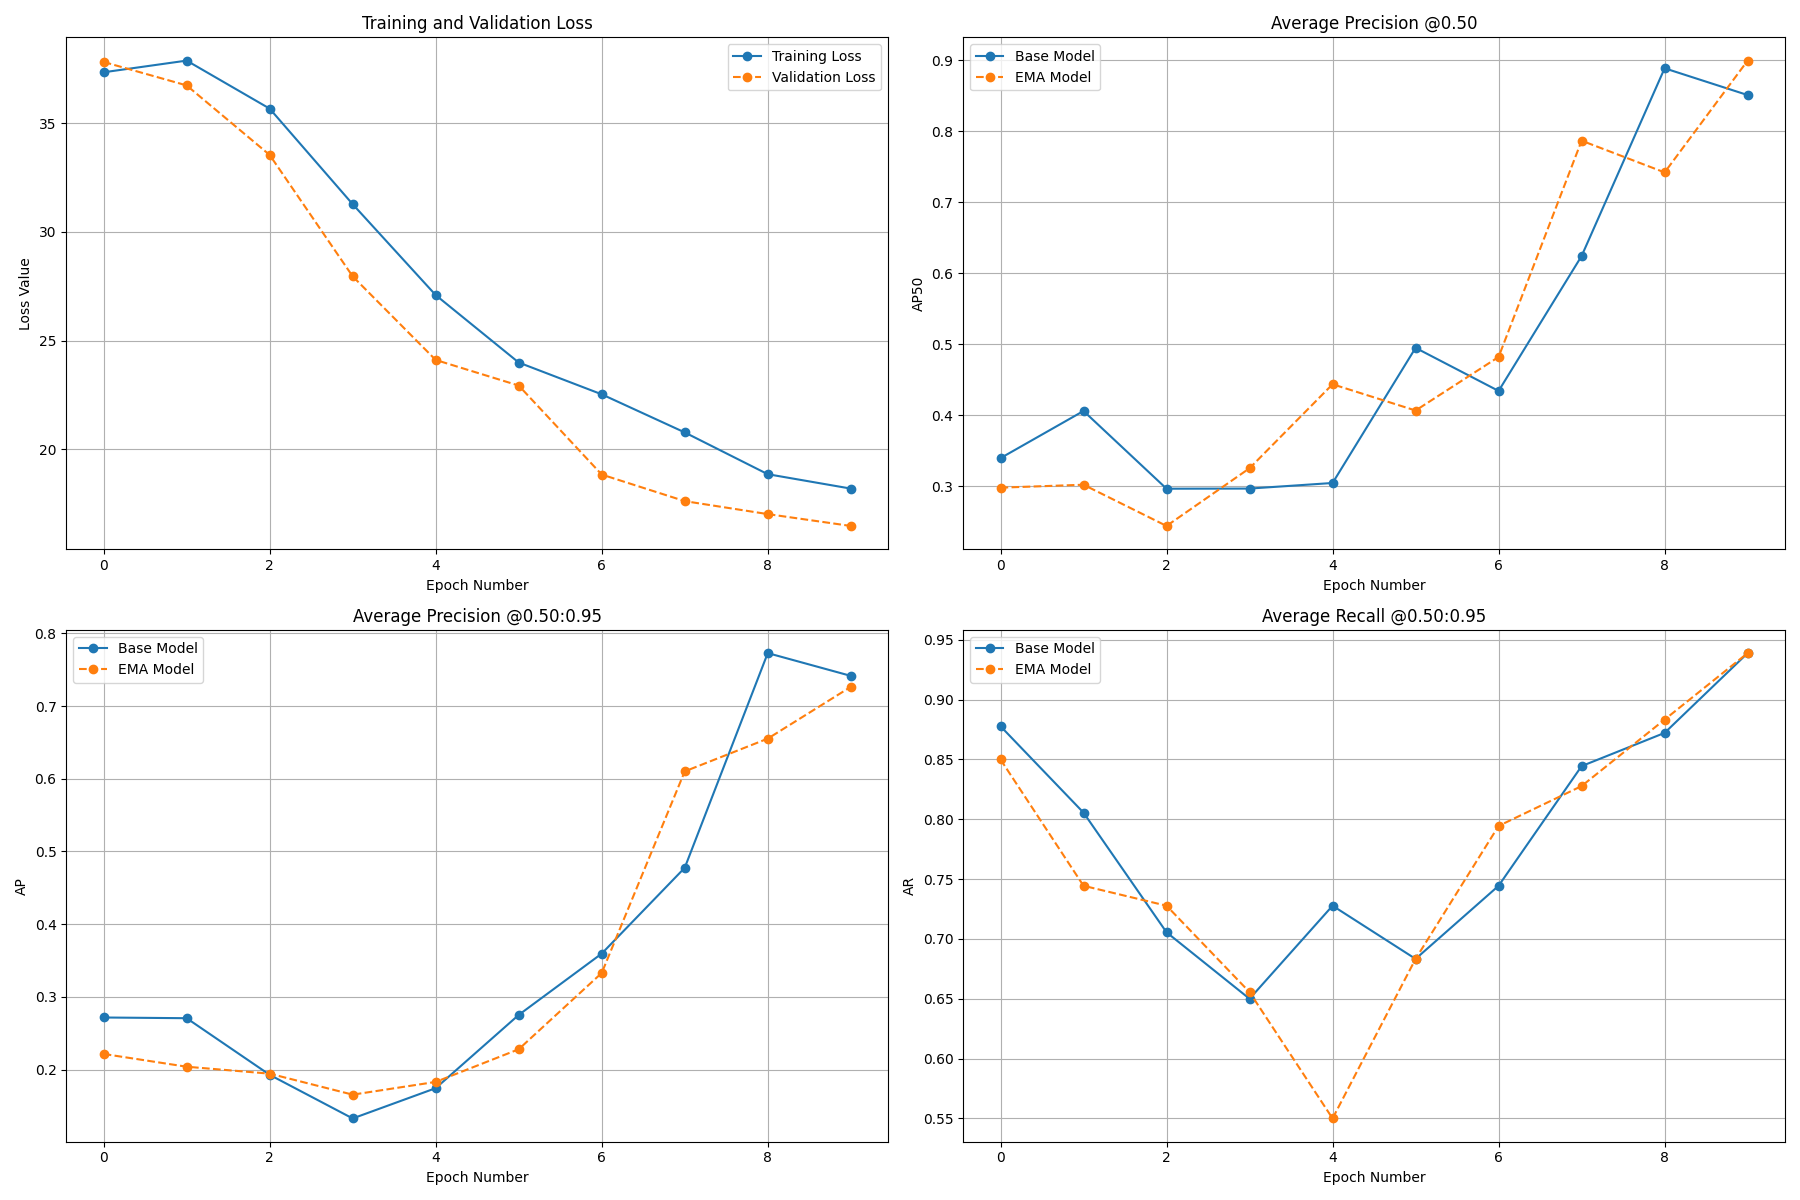

In [ ]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

The trained model is checkpoint_best_total.pth.

In [ ]:
!ls -la /content/output

total 1957720
drwxr-xr-x 3 root root      4096 Mar 25 16:28 .
drwxr-xr-x 1 root root      4096 Mar 25 16:22 ..
-rw-r--r-- 1 root root 534398511 Mar 25 16:27 checkpoint0009.pth
-rw-r--r-- 1 root root 399873726 Mar 25 16:26 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 401162890 Mar 25 16:27 checkpoint_best_regular.pth
-rw------- 1 root root 134529047 Mar 25 16:27 checkpoint_best_total.pth
-rw-r--r-- 1 root root 534387619 Mar 25 16:27 checkpoint.pth
drwxr-xr-x 2 root root      4096 Mar 25 16:23 eval
-rw-r--r-- 1 root root      4412 Mar 25 16:27 events.out.tfevents.1774455778.dd0666a08521.847.0
-rw-r--r-- 1 root root    112052 Mar 25 16:27 log.txt
-rw-r--r-- 1 root root    184552 Mar 25 16:28 metrics_plot.png
-rw-r--r-- 1 root root       863 Mar 25 16:28 results.json


### Install RF-DETR to CoreML

In [ ]:
!git clone https://github.com/landchenxuan/rf-detr-to-coreml.git
%cd rf-detr-to-coreml
!pip install -q -e .

Cloning into 'rf-detr-to-coreml'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 99 (delta 38), reused 87 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 1.71 MiB | 5.47 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/rf-detr-to-coreml
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.7 MB/s eta 0:00:00
  Building editable for rfdetr-coreml (pyproject.toml) ... done


Move the best model to the current folder and export to a Core ML model.

In [ ]:
!mv /content/output/checkpoint_best_total.pth .

In [ ]:
!rfdetr-coreml --model seg-nano --weights checkpoint_best_total.pth

scikit-learn version 1.6.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
XGBoost version 3.2.0 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
2026-03-25 16:29:05.411602: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774456145.439811    4073 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774456145.448839    4073 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774456145.483628    4073 computation_placer.cc:177] computation placer already registered. Please check linkage and 

In [ ]:
!ls -la output

total 12
drwxr-xr-x 3 root root 4096 Mar 25 16:29 .
drwxr-xr-x 7 root root 4096 Mar 25 16:29 ..
drwxr-xr-x 3 root root 4096 Mar 25 16:29 rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage


In [ ]:
%cd output

/content/rf-detr-to-coreml/output


Zip the Core ML model and download it from the File browser at the left hand. You can auto label images using the Core ML model on RectLabel.

In [ ]:
!zip -r seg-nano.zip rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage

  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/model.mlmodel (deflated 89%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/ (stored 0%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Data/com.apple.CoreML/weights/weight.bin (deflated 7%)
  adding: rf-detr-seg-nano-checkpoint_best_total-fp32.mlpackage/Manifest.json (deflated 60%)
